# Employee attrition prediction using Support Vector Machines (SVM)

## Project overview
Employee attrition is a major challenge for organizations because employee turnover increases recruitment costs and may reduce productivity. This project applies Support Vector Machine (SVM) classifiers to predict whether an employee is likely to leave the company based on workplace characteristics. Different kernel functions and hyperparameter optimization are evaluated to compare predictive performance.

## Import required libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the dataset

In [6]:
df = pd.read_csv('recursos_humanos.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Exploratory data analysis (EDA)

### Check the dataset general structure

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


### Check the number of missing values for each feature in the dataset

In [8]:
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

### Explore categorical features 

In [9]:
df['sales'].unique()

<StringArray>
[      'sales',  'accounting',          'hr',   'technical',     'support',
  'management',          'IT', 'product_mng',   'marketing',       'RandD']
Length: 10, dtype: str

In [10]:
df['salary'].unique()

<StringArray>
['low', 'medium', 'high']
Length: 3, dtype: str

### Exploratory visualization

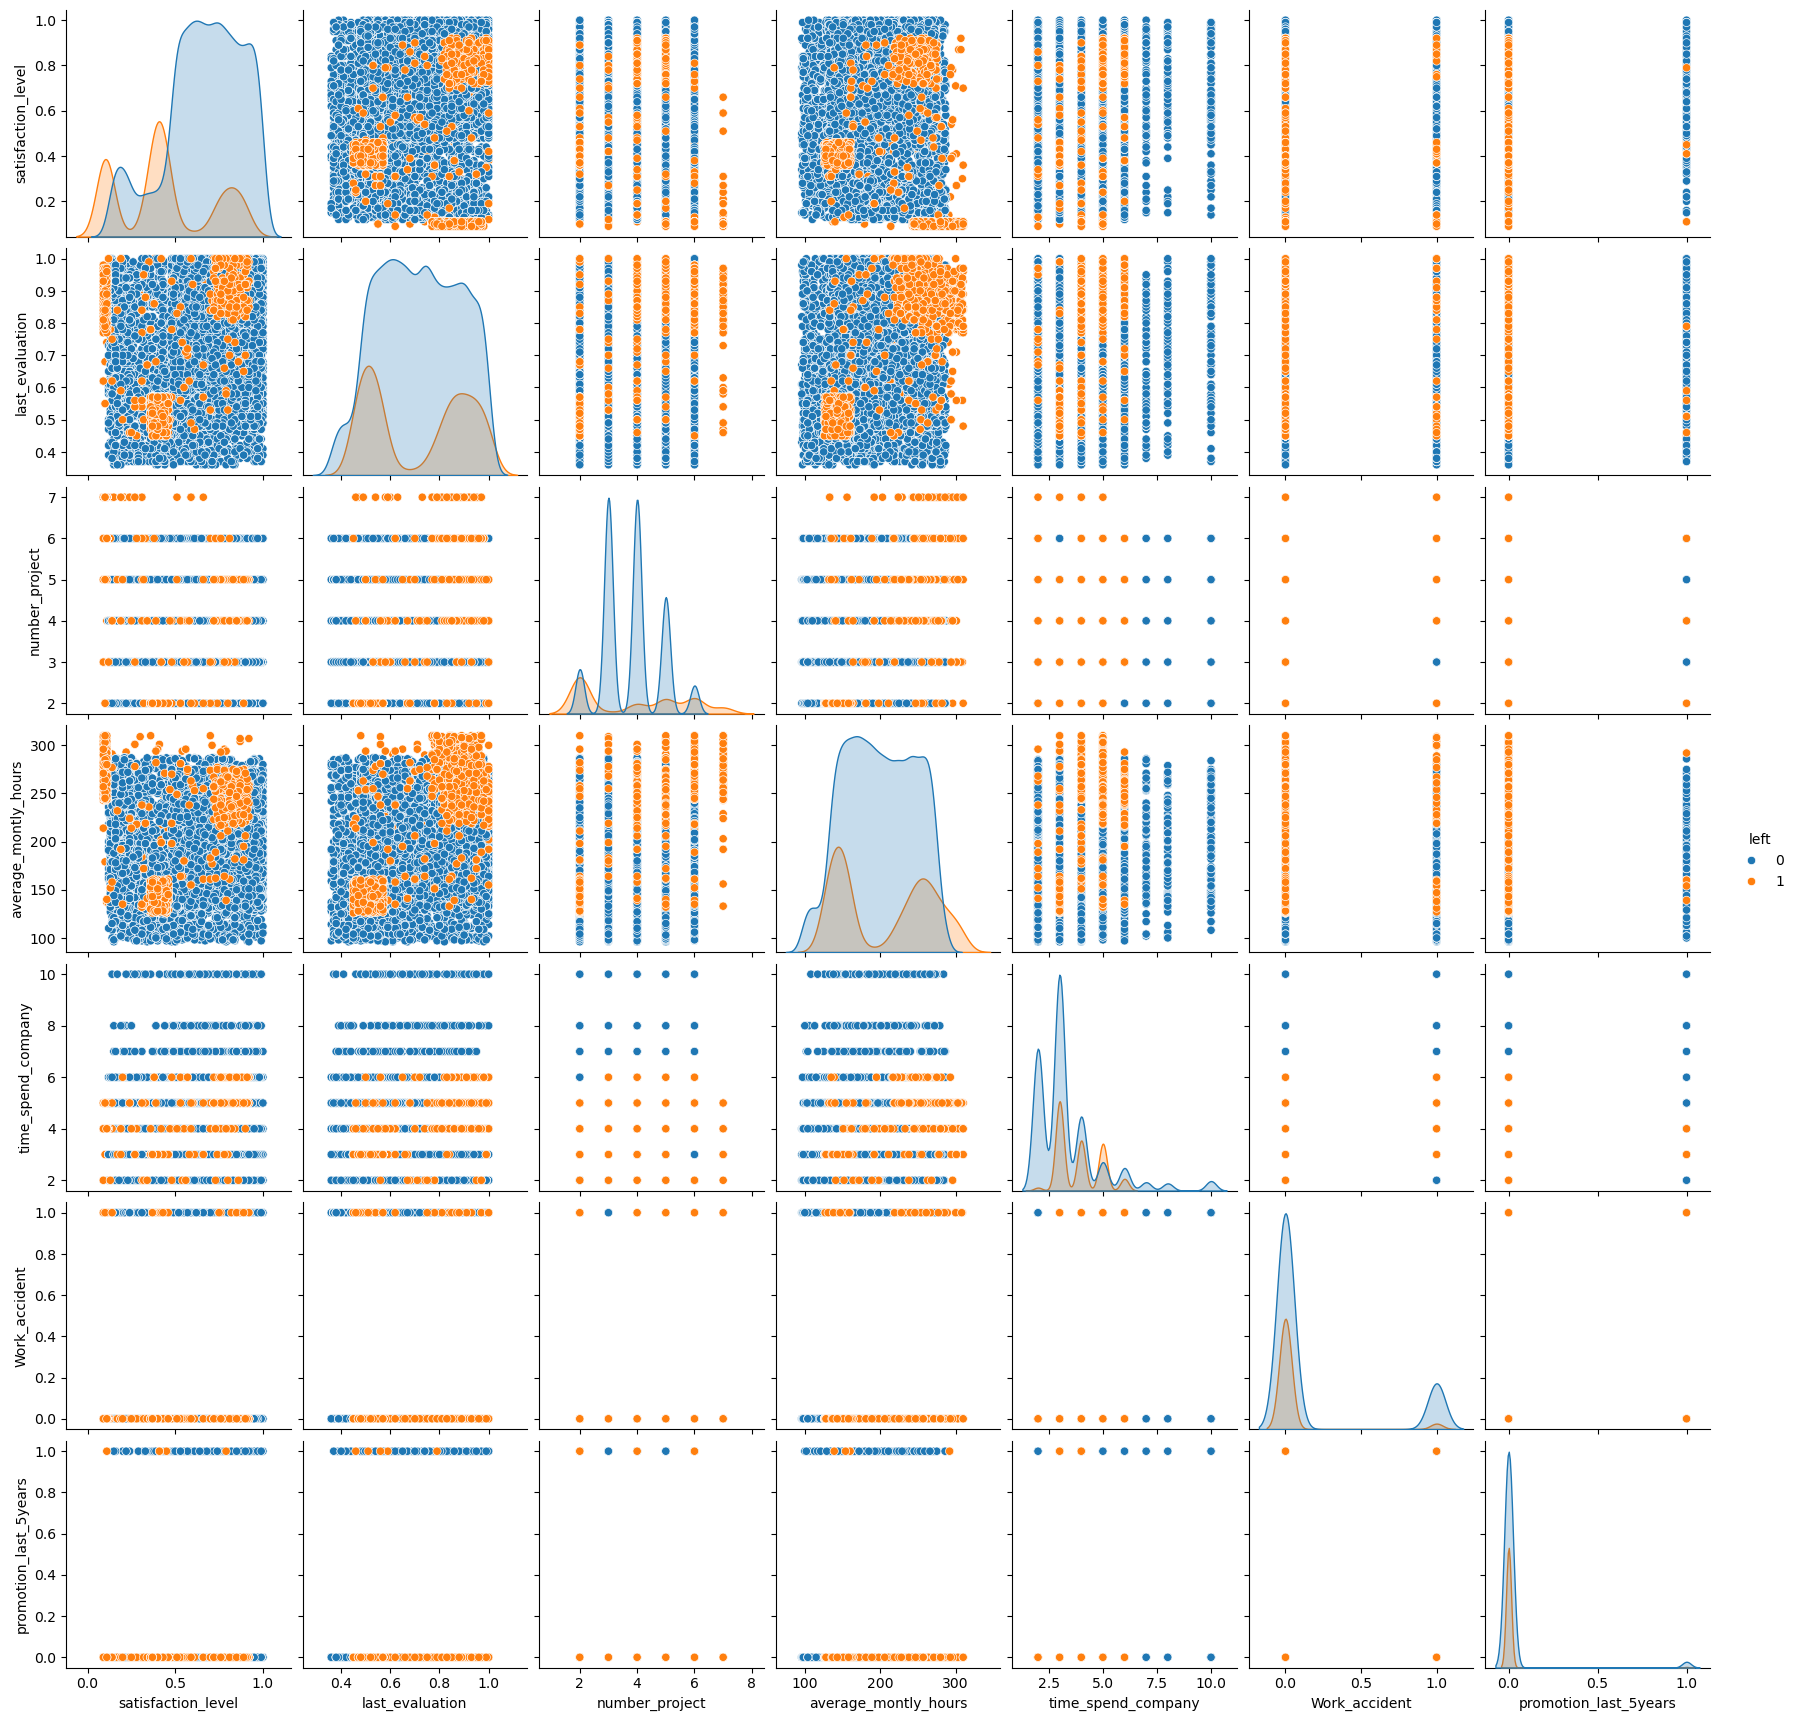

In [11]:
g = sns.pairplot(df, hue='left')
g.savefig('svm_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()

## Data preprocessing

In [13]:
# Create df_dummies
df_dummies = pd.get_dummies(df,drop_first = True)
# Print the new DataFrame's shape
print("Shape of df_dummies: {}".format(df_dummies.shape))
df_dummies['left'].value_counts()

Shape of df_dummies: (14999, 19)


left
0    11428
1     3571
Name: count, dtype: int64

In [14]:
df_dummies.dtypes

satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
sales_RandD                 bool
sales_accounting            bool
sales_hr                    bool
sales_management            bool
sales_marketing             bool
sales_product_mng           bool
sales_sales                 bool
sales_support               bool
sales_technical             bool
salary_low                  bool
salary_medium               bool
dtype: object

## Feature encoding

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = np.asarray(df_dummies.drop('left',axis = 1))
y = np.asarray(df_dummies['left'])
X[0:5]


array([[0.38, 0.53, 2, 157, 3, 0, 0, False, False, False, False, False,
        False, True, False, False, True, False],
       [0.8, 0.86, 5, 262, 6, 0, 0, False, False, False, False, False,
        False, True, False, False, False, True],
       [0.11, 0.88, 7, 272, 4, 0, 0, False, False, False, False, False,
        False, True, False, False, False, True],
       [0.72, 0.87, 5, 223, 5, 0, 0, False, False, False, False, False,
        False, True, False, False, True, False],
       [0.37, 0.52, 2, 159, 3, 0, 0, False, False, False, False, False,
        False, True, False, False, True, False]], dtype=object)

In [16]:
y[0:5]

array([1, 1, 1, 1, 1])

## Train-test split

In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.30,random_state = 42,stratify = y)
# Data scaling
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [18]:
print('Grupo de entrenamiento', scaled_X_train.shape, y_train.shape)
print('Grupo de prueba', scaled_X_test.shape,y_test.shape)

Grupo de entrenamiento (10499, 18) (10499,)
Grupo de prueba (4500, 18) (4500,)


## Build SVM models

In [19]:
from sklearn import svm

In [20]:
from sklearn.svm import SVC

In [21]:
baseline_model = svm.SVC(kernel = 'rbf')
baseline_model.fit(scaled_X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Model evaluation

### The trained SVM model is evaluated using predictions on the test set. Performance is assessed through the confusion matrix, classification report, and manually calculated evaluation metrics.

### Prediction on the test set

In [22]:
y_hat = baseline_model.predict(scaled_X_test)
y_hat[0:5]

array([0, 0, 0, 0, 0])

### Create confusion matrix

In [23]:
from sklearn.metrics import confusion_matrix, classification_report
baseline_predictions = baseline_model.predict(scaled_X_test)
cm = confusion_matrix(y_test,baseline_predictions)
cm

array([[3324,  105],
       [ 108,  963]])

### Confusion matrix visualization

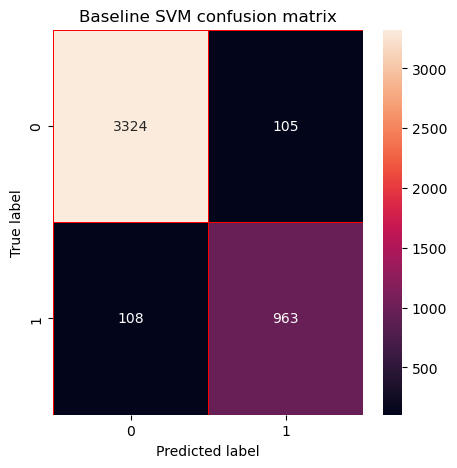

In [24]:
f, ax = plt.subplots(figsize=(5,5))

sns.heatmap(cm,annot=True,linewidth=0.5,linecolor='red',fmt='.0f',ax=ax)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Baseline SVM confusion matrix')
plt.savefig('svm_baseline_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

### Print classification report

In [37]:
print(classification_report(y_test,baseline_predictions))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3429
           1       0.90      0.90      0.90      1071

    accuracy                           0.95      4500
   macro avg       0.94      0.93      0.93      4500
weighted avg       0.95      0.95      0.95      4500



### Precision and recall are calculated manually from the confusion matrix to validate the results reported by Scikit-learn.

### Calculate precision for each class

In [38]:
Precision_noseva = cm[0,0]/(cm[0,0]+ cm[1,0])
print(np.round(Precision_noseva,2))


0.97


In [39]:
Precision_seva = cm[1,1]/(cm[1,1]+cm[0,1])
print(np.round(Precision_seva,2))

0.9


### Calculate recall for each class

In [40]:
Recall_noseva = cm[0,0]/(cm[0,0]+ cm[0,1]) 
print(np.round(Recall_noseva,2))

0.97


In [41]:
Recall_seva = cm[1,1]/(cm[1,0]+ cm[1,1])
print(np.round(Recall_seva,2))

0.9


### Evaluation metrics 
**Precision** measures the proportion of positive predictions that are correct.

**Recall** measures the proportion of actual positive cases that are correctly identified.

These metrics are calculated manually to illustrate how they are derived from the confusion matrix and then compared with the values reported by Scikit-learn.

## Hyperparameter tuning

In [42]:
from sklearn.model_selection import GridSearchCV
svm = SVC()

In [43]:
param_grid = {'C':[0.1,1,10],'kernel':['rbf','sigmoid','linear'],'gamma':['scale','auto']}

### Hyperparameter optimization using GridSearchCV

In [44]:
grid = GridSearchCV(svm,param_grid,cv = 3)

In [45]:
grid.fit(scaled_X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'sigmoid', ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information 

### Optimized SVM model

In [46]:
grid.best_params_

{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

In [47]:
optimized_model = grid.best_estimator_
optimized_model.fit(scaled_X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Optimized model evaluation

### Create optimized model confusion matrix 

In [48]:
from sklearn.metrics import confusion_matrix, classification_report
optimized_predictions = optimized_model.predict(scaled_X_test)
cm2 = confusion_matrix(y_test,optimized_predictions)
cm2

array([[3337,   92],
       [  95,  976]])

### Optimized model confusion matrix visualization

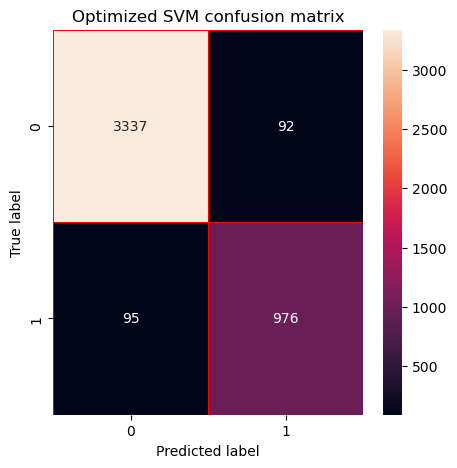

In [49]:
f, ax = plt.subplots(figsize=(5,5))

sns.heatmap(cm2,annot=True,linewidth=0.5,linecolor='red',fmt='.0f',ax=ax)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Optimized SVM confusion matrix')
plt.savefig('svm_optimized_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

### Print optimized model classification report

In [50]:
print(classification_report(y_test,optimized_predictions))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3429
           1       0.91      0.91      0.91      1071

    accuracy                           0.96      4500
   macro avg       0.94      0.94      0.94      4500
weighted avg       0.96      0.96      0.96      4500



## Conclusions

The baseline Support Vector Machine model achieved strong predictive performance for employee attrition classification, obtaining an overall accuracy of 95%.
Hyperparameter optimization using GridSearchCV selected an RBF kernel with C = 10 and gamma = scale. The optimized model slightly improved the classification performance, increasing the overall accuracy to 96% while also improving precision and recall for the employee attrition class.
Manual calculations of precision and recall matched the values reported by Scikit-learn, confirming the correctness of the evaluation metrics derived from the confusion matrix.
Future work could explore additional feature engineering, alternative classification algorithms, or hyperparameter optimization using the F1-score instead of accuracy. Since employee attrition is an imbalanced classification problem, optimizing for the F1-score could provide a better balance between precision and recall when identifying employees at risk of leaving the company.